<a href="https://colab.research.google.com/github/rahul1234500/python/blob/main/ml/Live_cricket_Predicition_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [21]:
# =========================
# 2. LOAD DATASET
# =========================
# Example: IPL dataset (tu apna CSV upload kare)
data = pd.read_csv('/content/ipl_2026_deliveries.csv')

In [22]:
# =========================
# 3. FEATURE ENGINEERING
# =========================

# Print columns to help identify correct names if 'over' or 'ball' are different
print(data.columns)

# Overs ko balls me convert (e.g., 1.3 = 9 balls)
# Assuming 'over' (integer for over number, e.g., 1-20) and each row is a delivery.
# Calculate ball number within each over
data['ball_in_over'] = data.groupby(['match_id', 'innings', 'over']).cumcount() + 1
data['balls_bowled'] = (data['over'] - 1) * 6 + data['ball_in_over']

# Total balls (T20 = 120)
data['balls_left'] = 120 - data['balls_bowled']

# Wickets remaining
# First, identify if a wicket fell on this ball
data['is_wicket'] = data['player_dismissed'].notna().astype(int)
# Calculate cumulative wickets taken in each innings
data['wickets_taken_in_innings'] = data.groupby(['match_id', 'innings'])['is_wicket'].cumsum()
# Calculate wickets left
data['wickets_left'] = 10 - data['wickets_taken_in_innings']

# Strike rates (commented out due to missing direct 'striker_runs', 'striker_balls' columns per delivery)
# These typically require cumulative stats for each player which are more complex to derive per delivery.
# data['striker_sr'] = (data['striker_runs'] / data['striker_balls']) * 100
# data['non_striker_sr'] = (data['non_striker_runs'] / data['non_striker_balls']) * 100

# Fill NaN (Note: This will fill NaNs in newly created columns too if any, e.g., for balls_bowled if over is NaN)
data.fillna(0, inplace=True)

Index(['match_id', 'season', 'phase', 'match_no', 'date', 'venue',
       'batting_team', 'bowling_team', 'innings', 'over', 'striker', 'bowler',
       'runs_of_bat', 'extras', 'wide', 'legbyes', 'byes', 'noballs',
       'wicket_type', 'player_dismissed', 'fielder'],
      dtype='object')


In [23]:
# =========================
# 4. SELECT FEATURES
# =========================

# Calculate current score for each delivery
data['current_score_in_innings'] = data.groupby(['match_id', 'innings'])['runs_of_bat'].cumsum() + \
                                   data.groupby(['match_id', 'innings'])['extras'].cumsum()

# Calculate final score for each innings and merge back
innings_scores = data.groupby(['match_id', 'innings']).agg(
    final_runs_of_bat=('runs_of_bat', 'sum'),
    final_extras=('extras', 'sum')
).reset_index()
innings_scores['final_score'] = innings_scores['final_runs_of_bat'] + innings_scores['final_extras']
data = pd.merge(data, innings_scores[['match_id', 'innings', 'final_score']], on=['match_id', 'innings'], how='left')

# Select features (X) and target (y)
X = data[['current_score_in_innings', 'wickets_left', 'balls_left']]
y = data['final_score']

In [24]:
# =========================
# 5. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [25]:
# =========================
# 6. MODEL TRAIN
# =========================
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

RandomForestRegressor()

In [26]:
# =========================
# 7. PREDICTION FUNCTION
# =========================
def predict_score(runs, wickets, overs, striker_runs, striker_balls, non_striker_runs, non_striker_balls):

    balls_bowled = int(overs)*6 + int((overs-int(overs))*10)
    balls_left = 120 - balls_bowled
    wickets_left = 10 - wickets

    # These were not used for training the model (as per X definition in step 4)
    # striker_sr = (striker_runs / striker_balls)*100 if striker_balls > 0 else 0
    # non_striker_sr = (non_striker_runs / non_striker_balls)*100 if non_striker_balls > 0 else 0

    # Model expects 3 features: current_score_in_innings, wickets_left, balls_left
    input_data = np.array([[runs, wickets_left, balls_left]])

    pred = model.predict(input_data)[0]

    return int(pred)

In [29]:
print(predict_score(
    runs=100,
    wickets=5,
    overs=11,
    striker_runs=50,
    striker_balls=20,
    non_striker_runs=50,
    non_striker_balls=15
))

153


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [30]:
# =========================
# 8. STORE DATA IN DATABASE
# =========================
import sqlite3

# Create an in-memory SQLite database connection
# For a file-based database, replace ':memory:' with a file path like 'ipl_database.db'
conn = sqlite3.connect(':memory:')

# Store the 'data' DataFrame into a SQL table named 'ipl_data'
data.to_sql('ipl_data', conn, if_exists='replace', index=False)

print("Data stored in SQLite database successfully in table 'ipl_data'.")

# You can optionally verify by querying the database
# query_df = pd.read_sql('SELECT * FROM ipl_data LIMIT 5', conn)
# print(query_df)

# Close the connection when done (or keep open if you intend to query more)
# conn.close()

Data stored in SQLite database successfully in table 'ipl_data'.


In [31]:
query_df = pd.read_sql('SELECT * FROM ipl_data LIMIT 5', conn)
display(query_df)

,match_id,season,phase,match_no,date,venue,batting_team,bowling_team,innings,over,...,player_dismissed,fielder,ball_in_over,balls_bowled,balls_left,is_wicket,wickets_taken_in_innings,wickets_left,current_score_in_innings,final_score
0,202601,2026,Group Stage,1,"Mar 28, 2026","M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.1,...,0,0,1,-4.4,124.4,0,0,10,0,203
1,202601,2026,Group Stage,1,"Mar 28, 2026","M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.2,...,0,0,1,-3.8,123.8,0,0,10,1,203
2,202601,2026,Group Stage,1,"Mar 28, 2026","M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.3,...,0,0,1,-3.2,123.2,0,0,10,1,203
3,202601,2026,Group Stage,1,"Mar 28, 2026","M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.4,...,0,0,1,-2.6,122.6,0,0,10,7,203
4,202601,2026,Group Stage,1,"Mar 28, 2026","M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.5,...,0,0,1,-2.0,122.0,0,0,10,7,203


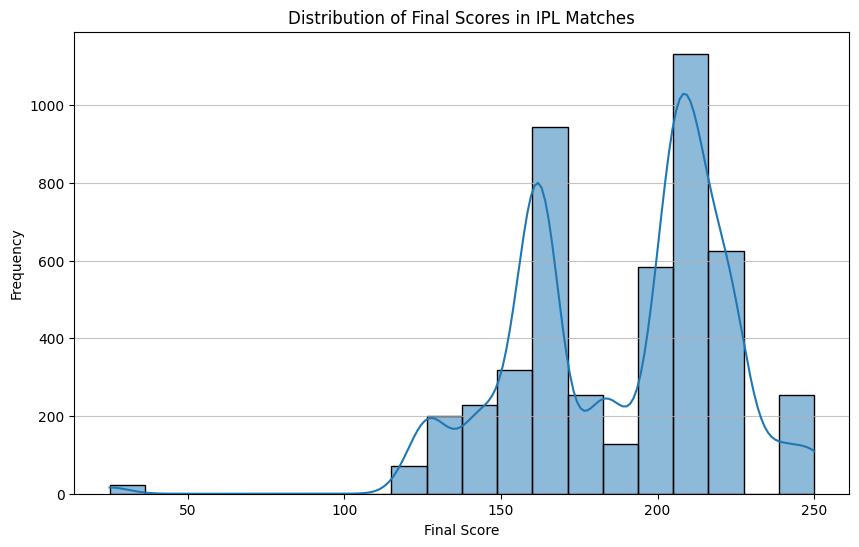

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(data['final_score'], bins=20, kde=True)
plt.title('Distribution of Final Scores in IPL Matches')
plt.xlabel('Final Score')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()